# Signals Study – Full Analysis (Hardcoded Paths)

Diagnostic analysis of the current detectors on CERT r5.2:

- Rule-based Scenario-1 exfil chain  
- Anomaly (Isolation Forest + z-score baselines)  
- Supervised ML detector (14-day flattened windows)  
- Scenario-1 forecasting model (7-day horizon)

This notebook only reads existing artifacts. It does not modify detectors or UI.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

ALERTS_PATH = Path("/Users/jordanchambers/capstone_6019/out/r5.2/alerts_full/alerts.ndjson")
INSIDERS_PATH = Path("/Users/jordanchambers/capstone_6019/answers/insiders.csv")
DAILY_USER_PATH = Path("/Users/jordanchambers/capstone_6019/out/r5.2/features_v2/daily_user/daily_user.parquet")

print("Alerts:", ALERTS_PATH, ALERTS_PATH.exists())
print("Insiders:", INSIDERS_PATH, INSIDERS_PATH.exists())
print("daily_user:", DAILY_USER_PATH, DAILY_USER_PATH.exists())

if not ALERTS_PATH.exists():
    raise FileNotFoundError(f"Missing alerts file: {ALERTS_PATH}")
if not INSIDERS_PATH.exists():
    raise FileNotFoundError(f"Missing insiders file: {INSIDERS_PATH}")
if not DAILY_USER_PATH.exists():
    raise FileNotFoundError(f"Missing daily_user file: {DAILY_USER_PATH}")


Alerts: /Users/jordanchambers/capstone_6019/out/r5.2/alerts_full/alerts.ndjson True
Insiders: /Users/jordanchambers/capstone_6019/answers/insiders.csv True
daily_user: /Users/jordanchambers/capstone_6019/out/r5.2/features_v2/daily_user/daily_user.parquet True


## 1. Load Alerts & Unpack Anomaly Evidence

Assumes alerts_full rows look like:

- day (timestamp)  
- user_key (lowercased username key)  
- detector in {rules, anomaly, ml, forecast, …}  
- score in [0, 1]  
- evidence (dict) for detector-specific details


In [2]:
alerts_df = pd.read_json(ALERTS_PATH, lines=True)
alerts_df['day'] = pd.to_datetime(alerts_df['day'])
alerts_df['user_key'] = alerts_df['user_key'].astype(str).str.lower()

print("Alerts shape:", alerts_df.shape)
print(alerts_df['detector'].value_counts())
alerts_df.head()


Alerts shape: (79175, 10)
detector
anomaly     75710
forecast     2201
rules         631
loop          517
ml            116
Name: count, dtype: int64


,day,user_key,detector,reason,score,evidence,human_summary,rules_score,anomaly_score,forecast_score
0,2010-01-02,aab1302,loop,heartbeat,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-03,acc0950,loop,heartbeat,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,emr0269,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
3,2010-01-04,vrp0267,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
4,2010-01-04,aab1302,loop,heartbeat,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def safe_dict(x):
    return x if isinstance(x, dict) else {}

alerts_df['evidence_dict'] = alerts_df['evidence'].apply(safe_dict)

for col_name, key in [
    ('anom_raw', 'anomaly_score_raw'),
    ('anom_boosted', 'anomaly_score_boosted'),
    ('anom_boost_pct', 'boost_pct'),
    ('z_personal', 'z_personal'),
    ('z_role', 'z_role'),
    ('z_max', 'z_max'),
    ('window_end', 'window_end'),
]:
    alerts_df[col_name] = alerts_df['evidence_dict'].apply(lambda d, k=key: d.get(k))

anomaly_df = alerts_df[alerts_df['detector'] == 'anomaly'].copy()
print("Anomaly alerts:", anomaly_df.shape[0])
anomaly_df[['day', 'user_key', 'score', 'anom_boosted', 'z_max']].head()


Anomaly alerts: 75710


,day,user_key,score,anom_boosted,z_max
78,2010-01-08,atd0517,0.585823,0.5858,NaN
85,2010-01-08,ddr1876,0.521751,0.5218,NaN
87,2010-01-08,emr0269,0.637295,0.6373,NaN
91,2010-01-08,gat1343,0.592649,0.5926,NaN
95,2010-01-08,hre1950,0.642666,0.6427,NaN


## 2. Scenario-1 Ground Truth (Insiders)

Use answers/insiders.csv and restrict to CERT r5.2 Scenario-1.


In [4]:
insiders = pd.read_csv(INSIDERS_PATH)
print("Insiders head:")
display(insiders.head())

s1_insiders = insiders.query("dataset == 5.2 and scenario == 1").copy()
s1_insiders['user_key'] = s1_insiders['user'].astype(str).str.lower()
s1_insiders['exfil_start'] = pd.to_datetime(s1_insiders['start'], format='%m/%d/%Y %H:%M:%S')
s1_insiders['exfil_end'] = pd.to_datetime(s1_insiders['end'], format='%m/%d/%Y %H:%M:%S')

s1_insiders = s1_insiders[['user_key', 'exfil_start', 'exfil_end']]
print("Scenario-1 insiders:", s1_insiders.shape[0])
display(s1_insiders.head())

S1_USERS = set(s1_insiders['user_key'])
print("Unique S1 users:", len(S1_USERS))

exfil_map = s1_insiders.set_index('user_key')[['exfil_start', 'exfil_end']].to_dict(orient='index')


Insiders head:


,dataset,scenario,details,user,start,end
0,2.0,1,r2.csv,ONS0995,3/6/2010 1:41:56,3/20/2010 8:10:12
1,3.1,1,r3.1-1.csv,CSF0929,07/01/2010 01:24:58,07/16/2010 06:52:00
2,3.1,2,r3.1-2.csv,CCH0959,08/02/2010 10:34:31,09/30/2010 15:04:03
3,3.2,1,r3.2-1.csv,RCW0822,09/29/2010 21:10:27,10/15/2010 06:34:52
4,3.2,2,r3.2-2.csv,JCE0258,07/12/2010 08:16:02,09/03/2010 16:16:29


Scenario-1 insiders: 29


,user_key,exfil_start,exfil_end
82,alt1465,2010-08-13 22:16:10,2010-08-20 04:01:32
83,alw0764,2011-02-03 07:09:09,2011-02-05 06:12:51
84,ayg1697,2010-10-25 23:19:22,2010-10-26 00:06:28
85,das1320,2010-07-09 01:14:15,2010-07-15 01:38:58
86,dnj0740,2010-10-04 19:56:42,2010-10-05 01:01:37


Unique S1 users: 29


## 3. Per-Insider Timelines

For each Scenario-1 insider, visualize:

- Anomaly score over time  
- ML score over time  
- Rule hits (binary stem)  
- Forecast scores  

All aligned around exfil_start.


Example insider: alt1465


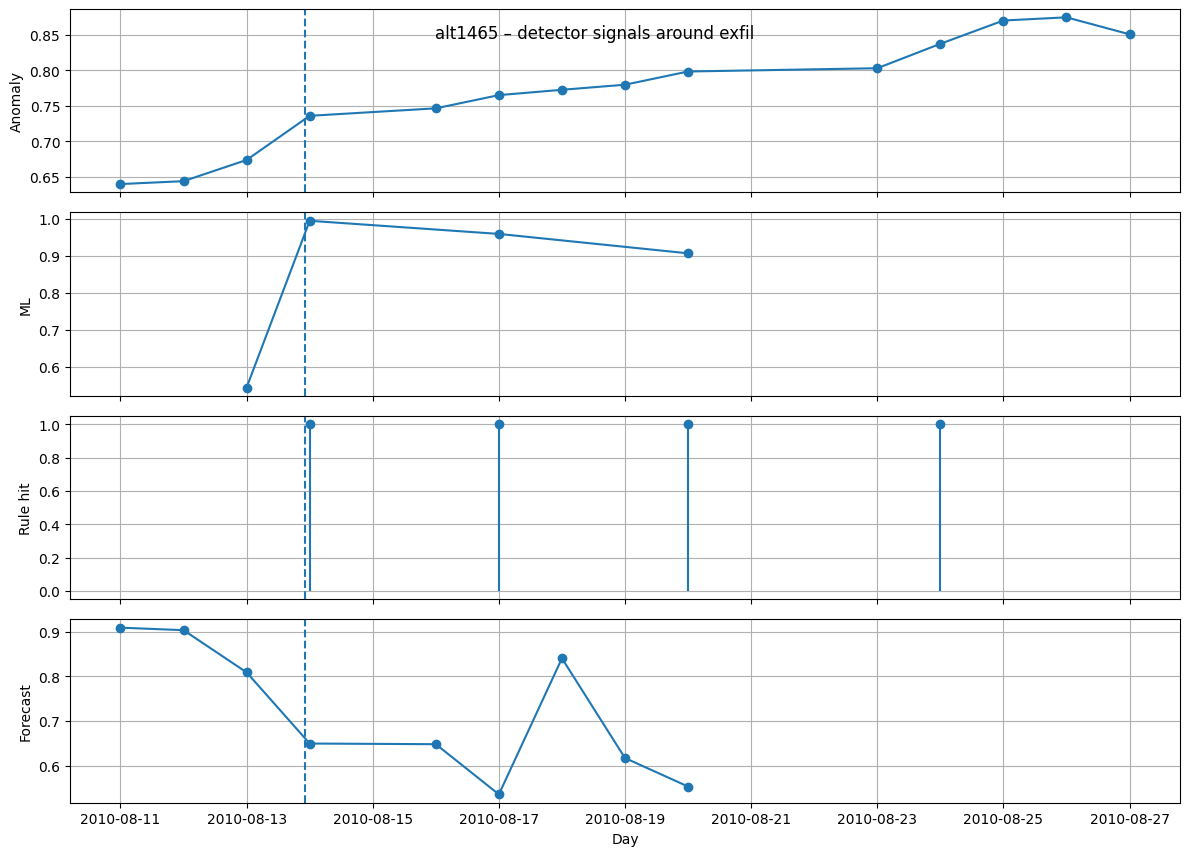

In [5]:
def get_user_alerts(user_key: str) -> pd.DataFrame:
    u = user_key.lower()
    df = alerts_df[alerts_df['user_key'] == u].copy()
    return df.sort_values('day')

def get_exfil_window(user_key: str):
    info = exfil_map.get(user_key.lower())
    if not info:
        return None, None
    return info['exfil_start'], info['exfil_end']

def plot_user_timeline(user_key: str, days_before: int = 120, days_after: int = 14):
    user_key = user_key.lower()
    df_u = get_user_alerts(user_key)
    if df_u.empty:
        print(f"No alerts for {user_key}")
        return

    ex_start, ex_end = get_exfil_window(user_key)
    if ex_start is None:
        print(f"No Scenario-1 entry for {user_key}")
        return

    start = (ex_start - pd.Timedelta(days=days_before)).normalize()
    end = (ex_start + pd.Timedelta(days=days_after)).normalize()
    df_u = df_u[(df_u['day'] >= start) & (df_u['day'] <= end)]
    if df_u.empty:
        print(f"No alerts in window for {user_key}")
        return

    anom = df_u[df_u['detector'] == 'anomaly'][['day', 'score']].rename(columns={'score': 'anom_score'})
    ml = df_u[df_u['detector'] == 'ml'][['day', 'score']].rename(columns={'score': 'ml_score'})
    rules = df_u[df_u['detector'] == 'rules'][['day', 'reason']]
    fore = df_u[df_u['detector'] == 'forecast'][['day', 'score']].rename(columns={'score': 'forecast_score'})

    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    fig.suptitle(f"{user_key} – detector signals around exfil", y=0.93)

    if not anom.empty:
        axes[0].plot(anom['day'], anom['anom_score'], marker='o')
    axes[0].set_ylabel("Anomaly")

    if not ml.empty:
        axes[1].plot(ml['day'], ml['ml_score'], marker='o')
    axes[1].set_ylabel("ML")

    if not rules.empty:
        r = rules.copy()
        r['hit'] = 1.0
        axes[2].stem(r['day'], r['hit'], basefmt=' ')
    axes[2].set_ylabel("Rule hit")

    if not fore.empty:
        axes[3].plot(fore['day'], fore['forecast_score'], marker='o')
    axes[3].set_ylabel("Forecast")
    axes[3].set_xlabel("Day")

    for ax in axes:
        ax.axvline(ex_start, linestyle='--')
    plt.tight_layout()
    plt.show()

if S1_USERS:
    example_user = sorted(S1_USERS)[0]
    print("Example insider:", example_user)
    plot_user_timeline(example_user)
else:
    print("No Scenario-1 insiders found.")


## 4. Global Distributions – Anomaly vs Non-Insiders

Compare boosted anomaly scores and z_max for Scenario-1 insiders vs everyone else.


In [6]:
alerts_df['is_s1_insider'] = alerts_df['user_key'].isin(S1_USERS)

anom_all = alerts_df[alerts_df['detector'] == 'anomaly'].copy()
anom_all['score'] = anom_all['score'].astype(float)
anom_all['z_max'] = pd.to_numeric(anom_all['z_max'], errors='coerce')

print("Anomaly alerts – insider flag counts:")
print(anom_all['is_s1_insider'].value_counts())
anom_all[['day', 'user_key', 'score', 'z_max', 'is_s1_insider']].head()


Anomaly alerts – insider flag counts:
is_s1_insider
False    75117
True       593
Name: count, dtype: int64


,day,user_key,score,z_max,is_s1_insider
78,2010-01-08,atd0517,0.585823,NaN,False
85,2010-01-08,ddr1876,0.521751,NaN,False
87,2010-01-08,emr0269,0.637295,NaN,False
91,2010-01-08,gat1343,0.592649,NaN,False
95,2010-01-08,hre1950,0.642666,NaN,False


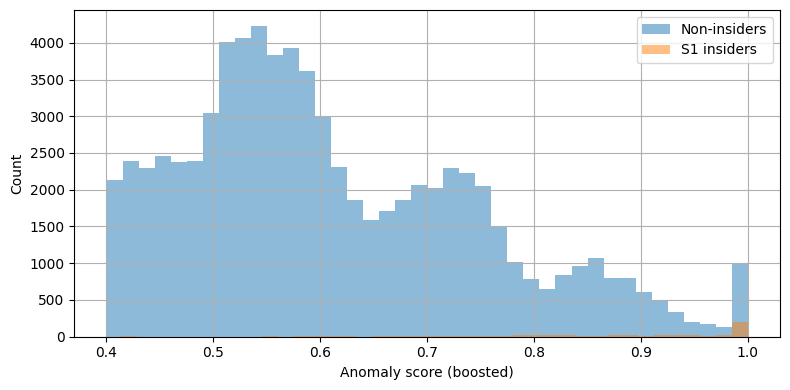

In [7]:
# Histogram: boosted anomaly score insiders vs non-insiders
fig, ax = plt.subplots(figsize=(8, 4))

ins_scores = anom_all[anom_all['is_s1_insider']]['score'].dropna()
non_scores = anom_all[~anom_all['is_s1_insider']]['score'].dropna()

ax.hist(non_scores, bins=40, alpha=0.5, label="Non-insiders")
ax.hist(ins_scores, bins=40, alpha=0.5, label="S1 insiders")
ax.set_xlabel("Anomaly score (boosted)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


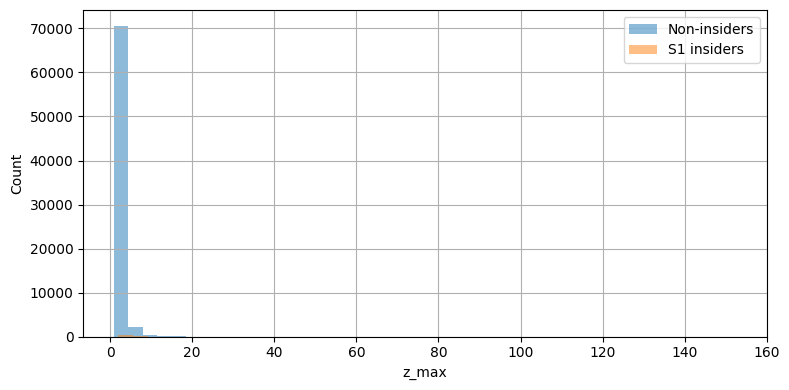

In [8]:
# Histogram: z_max insiders vs non-insiders
fig, ax = plt.subplots(figsize=(8, 4))

ins_z = anom_all[anom_all['is_s1_insider']]['z_max'].dropna()
non_z = anom_all[~anom_all['is_s1_insider']]['z_max'].dropna()

ax.hist(non_z, bins=40, alpha=0.5, label="Non-insiders")
ax.hist(ins_z, bins=40, alpha=0.5, label="S1 insiders")
ax.set_xlabel("z_max")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


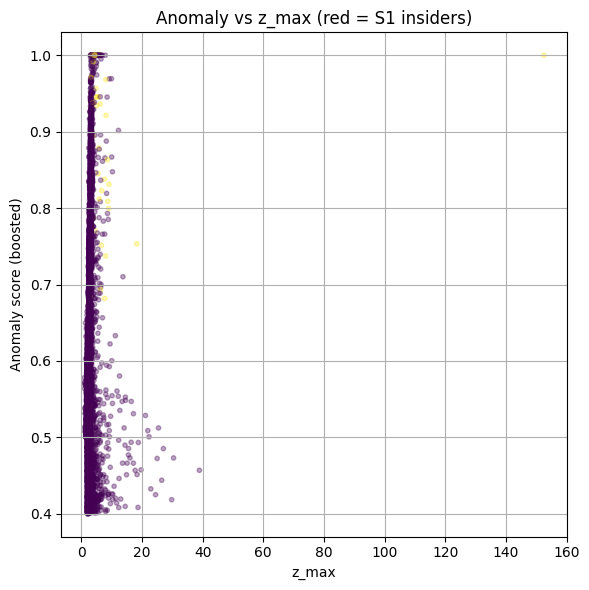

In [9]:
# Scatter: z_max vs boosted anomaly
sample = anom_all.dropna(subset=['z_max', 'score']).copy()
if sample.shape[0] > 8000:
    sample = sample.sample(8000, random_state=42)

colors = np.where(sample['is_s1_insider'], 1, 0)

plt.figure(figsize=(6, 6))
plt.scatter(sample['z_max'], sample['score'], s=10, alpha=0.35, c=colors)
plt.xlabel("z_max")
plt.ylabel("Anomaly score (boosted)")
plt.title("Anomaly vs z_max (red = S1 insiders)")
plt.tight_layout()
plt.show()


## 5. Pre-Exfil Structure (Anomaly)

For each Scenario-1 insider with anomaly alerts, compare:

- Baseline: [-90, -31] days before exfil_start  
- Pre-exfil: [-30, 0) days before exfil_start  

We look at mean and max anomaly scores in each window.


In [10]:
rows = []
for user_key, ex in exfil_map.items():
    ex_start = ex['exfil_start']
    df_u = anom_all[anom_all['user_key'] == user_key].copy()
    if df_u.empty:
        continue

    pre = df_u[(df_u['day'] >= ex_start - pd.Timedelta(days=30)) & (df_u['day'] < ex_start)]
    base = df_u[(df_u['day'] >= ex_start - pd.Timedelta(days=90)) & (df_u['day'] < ex_start - pd.Timedelta(days=30))]

    rows.append({
        "user_key": user_key,
        "pre_mean": pre['score'].mean() if not pre.empty else np.nan,
        "pre_max": pre['score'].max() if not pre.empty else np.nan,
        "base_mean": base['score'].mean() if not base.empty else np.nan,
        "base_max": base['score'].max() if not base.empty else np.nan,
    })

pre_vs_base = pd.DataFrame(rows)
display(pre_vs_base)

mask = pre_vs_base['pre_mean'].notna() & pre_vs_base['base_mean'].notna()
cmp = pre_vs_base[mask]

if not cmp.empty:
    frac_mean_up = (cmp['pre_mean'] > cmp['base_mean']).mean()
    frac_max_up = (cmp['pre_max'] > cmp['base_max']).mean()
    print("Frac users with higher pre-exfil MEAN anomaly than baseline:", round(frac_mean_up, 3))
    print("Frac users with higher pre-exfil MAX anomaly than baseline:", round(frac_max_up, 3))
else:
    print("No valid pre/baseline comparisons.")


,user_key,pre_mean,pre_max,base_mean,base_max
0,alt1465,0.652172,0.673463,NaN,NaN
1,alw0764,0.685232,0.882969,NaN,NaN
2,ayg1697,0.413650,0.413650,NaN,NaN
3,das1320,0.620443,0.804181,0.430001,0.436127
4,dnj0740,0.809712,0.870347,NaN,NaN
5,elt1370,0.566981,0.594782,NaN,NaN
6,epg1196,0.791946,0.825674,NaN,NaN
7,etw0002,0.871511,0.929766,NaN,NaN
8,fzg0389,0.718225,0.749523,NaN,NaN
9,gfm1815,0.999143,1.000000,NaN,NaN


Frac users with higher pre-exfil MEAN anomaly than baseline: 1.0
Frac users with higher pre-exfil MAX anomaly than baseline: 1.0


## 6. Cross-Prong Interactions (Anomaly vs daily_user Features)

Join anomaly alerts to daily_user and see whether high anomaly spikes align with:

- After-hours activity  
- USB connects  
- Wikileaks hits  
- Post-departure events  


In [11]:
con = duckdb.connect(database=":memory:")

anom_for_join = anom_all[['user_key', 'day', 'score']].copy()
anom_for_join['day_date'] = anom_for_join['day'].dt.date

con.register("anom", anom_for_join)

query = f"""
SELECT
  a.user_key,
  a.day_date AS day,
  a.score AS anomaly_score,
  d.logon_after_hours_rate,
  d.device_n_usb_connects,
  d.http_n_wikileaks,
  d.logon_n_events_post_departure,
  d.device_n_events_post_departure,
  d.file_n_events_post_departure,
  d.http_n_events_post_departure,
  d.email_n_events_post_departure
FROM anom a
JOIN read_parquet('{DAILY_USER_PATH.as_posix()}') d
  ON lower(d.user_key) = a.user_key
 AND CAST(d.day AS DATE) = a.day_date
"""

anom_feat = con.execute(query).df()
con.close()

print("Anomaly+features rows:", anom_feat.shape)
anom_feat.head()


Anomaly+features rows: (75710, 11)


,user_key,day,anomaly_score,logon_after_hours_rate,device_n_usb_connects,http_n_wikileaks,logon_n_events_post_departure,device_n_events_post_departure,file_n_events_post_departure,http_n_events_post_departure,email_n_events_post_departure
0,aab1302,2010-01-09,0.582153,0.333333,7.0,0.0,0.0,0.0,0.0,0.0,0.0
1,aab1302,2010-01-11,0.605632,0.333333,7.0,0.0,0.0,0.0,0.0,0.0,0.0
2,aab1302,2010-01-12,0.611579,0.500000,8.0,0.0,0.0,0.0,NaN,0.0,0.0
3,aab1302,2010-01-13,0.612188,0.000000,8.0,0.0,0.0,0.0,NaN,0.0,0.0
4,aab1302,2010-01-14,0.622541,0.500000,8.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
thr = 0.7
anom_feat['is_spike'] = anom_feat['anomaly_score'] >= thr

anom_feat['has_after_hours'] = anom_feat['logon_after_hours_rate'] > 0
anom_feat['has_usb'] = anom_feat['device_n_usb_connects'] > 0
anom_feat['has_wikileaks'] = anom_feat['http_n_wikileaks'] > 0
anom_feat['has_post_departure'] = (
    (anom_feat['logon_n_events_post_departure'] > 0) |
    (anom_feat['device_n_events_post_departure'] > 0) |
    (anom_feat['file_n_events_post_departure'] > 0) |
    (anom_feat['http_n_events_post_departure'] > 0) |
    (anom_feat['email_n_events_post_departure'] > 0)
)

def rate(col, mask=None):
    df = anom_feat if mask is None else anom_feat[mask]
    return float(df[col].mean()) if not df.empty else np.nan

summary = []
for col in ['has_after_hours', 'has_usb', 'has_wikileaks', 'has_post_departure']:
    summary.append({
        "feature": col,
        "overall_rate": rate(col),
        "spike_rate": rate(col, anom_feat['is_spike'])
    })

summary_df = pd.DataFrame(summary)
display(summary_df)


,feature,overall_rate,spike_rate
0,has_after_hours,0.459028,0.641604
1,has_usb,0.777823,0.911232
2,has_wikileaks,0.000832,0.002687
3,has_post_departure,0.044578,0.057306


## 7. Timing vs Exfil – Anomaly vs ML vs Forecast

For each Scenario-1 insider:

- Find the first strong spike for each detector:  
  - anomaly: score ≥ 0.7  
  - ML: score ≥ 0.7  
  - forecast: score ≥ 0.6  
- Compute lead time in days: exfil_start - first_spike_day.


In [13]:
rows = []

for user_key, ex in exfil_map.items():
    ex_start = ex['exfil_start']

    df_u = alerts_df[alerts_df['user_key'] == user_key].copy()
    if df_u.empty:
        continue

    start = (ex_start - pd.Timedelta(days=90)).normalize()
    end = (ex_start + pd.Timedelta(days=7)).normalize()
    df_u = df_u[(df_u['day'] >= start) & (df_u['day'] <= end)]
    if df_u.empty:
        continue

    def first_spike(det_name: str, thr: float):
        sub = df_u[df_u['detector'] == det_name].copy()
        if sub.empty:
            return None
        per_day = sub.groupby(sub['day'].dt.normalize())['score'].max()
        spike_days = per_day[per_day >= thr].index
        return spike_days.min() if len(spike_days) > 0 else None

    anom_first = first_spike("anomaly", 0.7)
    ml_first = first_spike("ml", 0.7)
    fore_first = first_spike("forecast", 0.6)

    def lead(first_day):
        if first_day is None:
            return np.nan
        return (ex_start.normalize() - first_day).days

    rows.append({
        "user_key": user_key,
        "anom_lead_days": lead(anom_first),
        "ml_lead_days": lead(ml_first),
        "forecast_lead_days": lead(fore_first),
    })

timing_df = pd.DataFrame(rows)
display(timing_df)

def summarize_lead(col):
    s = timing_df[col].dropna()
    if s.empty:
        return {"n": 0}
    return {
        "n": int(s.shape[0]),
        "min": float(s.min()),
        "median": float(s.median()),
        "max": float(s.max()),
    }

lead_summary = {
    "anom_lead_days": summarize_lead("anom_lead_days"),
    "ml_lead_days": summarize_lead("ml_lead_days"),
    "forecast_lead_days": summarize_lead("forecast_lead_days"),
}
lead_summary


,user_key,anom_lead_days,ml_lead_days,forecast_lead_days
0,alt1465,-1.0,-1.0,2.0
1,alw0764,2.0,0.0,3.0
2,ayg1697,-7.0,-1.0,0.0
3,das1320,0.0,0.0,79.0
4,dnj0740,3.0,0.0,7.0
5,elt1370,-5.0,-1.0,2.0
6,epg1196,6.0,0.0,6.0
7,etw0002,10.0,2.0,10.0
8,fzg0389,2.0,0.0,3.0
9,gfm1815,14.0,0.0,14.0


{'anom_lead_days': {'n': 28, 'min': -7.0, 'median': 1.5, 'max': 14.0},
 'ml_lead_days': {'n': 28, 'min': -7.0, 'median': 0.0, 'max': 3.0},
 'forecast_lead_days': {'n': 28, 'min': 0.0, 'median': 4.5, 'max': 79.0}}

In [14]:
#======= Per detector volume analysis for s1 insiders =======
# Build a quick lookup of exfil_start / exfil_end by user_key
s1_lookup = s1_insiders.set_index("user_key")[["exfil_start", "exfil_end"]].to_dict(orient="index")

def plot_user_detector_trends(user_key: str, days_before: int = 90, days_after: int = 14):
    """
    For a given Scenario-1 insider, plot daily detector scores around exfil:
    - anomaly: daily max score
    - ml:      daily max score
    - forecast: daily max score
    - rules:   0/1 (did rule fire that day?)
    """
    user_key = user_key.lower()
    meta = s1_lookup.get(user_key)
    if meta is None:
        print(f"No Scenario-1 metadata for {user_key}")
        return
    
    exfil_start = meta["exfil_start"]
    exfil_end   = meta["exfil_end"]
    
    # Time window
    start_day = (exfil_start - pd.Timedelta(days=days_before)).normalize()
    end_day   = (exfil_start + pd.Timedelta(days=days_after)).normalize()
    
    df_u = alerts_df[alerts_df["user_key"] == user_key].copy()
    df_u = df_u[(df_u["day"] >= start_day) & (df_u["day"] <= end_day)]
    if df_u.empty:
        print(f"No alerts for {user_key} in window.")
        return
    
    # Normalize to date granularity
    df_u["day_date"] = df_u["day"].dt.normalize()
    
    # Focus on the four detectors of interest
    dets = ["anomaly", "ml", "forecast", "rules"]
    df_u = df_u[df_u["detector"].isin(dets)]
    
    # For rules, treat as 0/1 (did we ever fire that day?)
    df_u["score_for_trend"] = df_u["score"].astype(float)
    rule_mask = df_u["detector"] == "rules"
    df_u.loc[rule_mask, "score_for_trend"] = 1.0  # any rule hit that day becomes 1
    
    # Daily max per detector
    daily = (
        df_u
        .groupby(["day_date", "detector"])["score_for_trend"]
        .max()
        .unstack("detector")
        .sort_index()
    )
    
    # Ensure all four detectors are present as columns (even if NaN)
    for d in dets:
        if d not in daily.columns:
            daily[d] = np.nan
    daily = daily[dets]
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.plot(daily.index, daily["anomaly"],  label="anomaly (score)",  marker="o", linewidth=1)
    ax.plot(daily.index, daily["ml"],       label="ml (score)",       marker="o", linewidth=1)
    ax.plot(daily.index, daily["forecast"], label="forecast (score)", marker="o", linewidth=1)
    ax.plot(daily.index, daily["rules"],    label="rules (0/1)",      marker="o", linewidth=1)
    
    # Exfil markers
    ax.axvline(exfil_start, color="red", linestyle="--", linewidth=1, label="exfil_start")
    if pd.notna(exfil_end) and exfil_end != exfil_start:
        ax.axvspan(exfil_start, exfil_end, color="red", alpha=0.1)
    
    ax.set_title(f"{user_key} – detector trends around exfil")
    ax.set_xlabel("Day")
    ax.set_ylabel("Daily max score (rules = 0/1)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

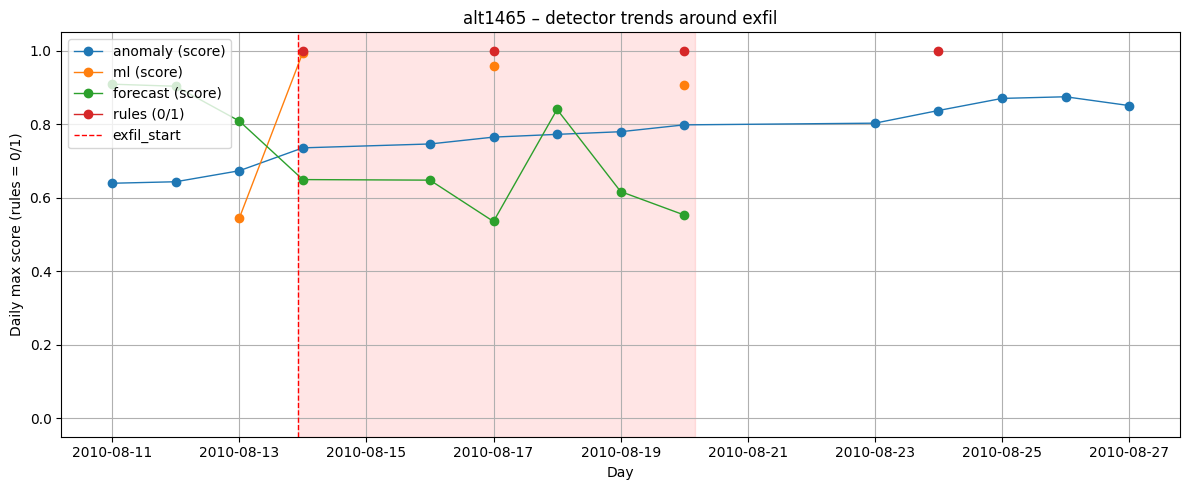

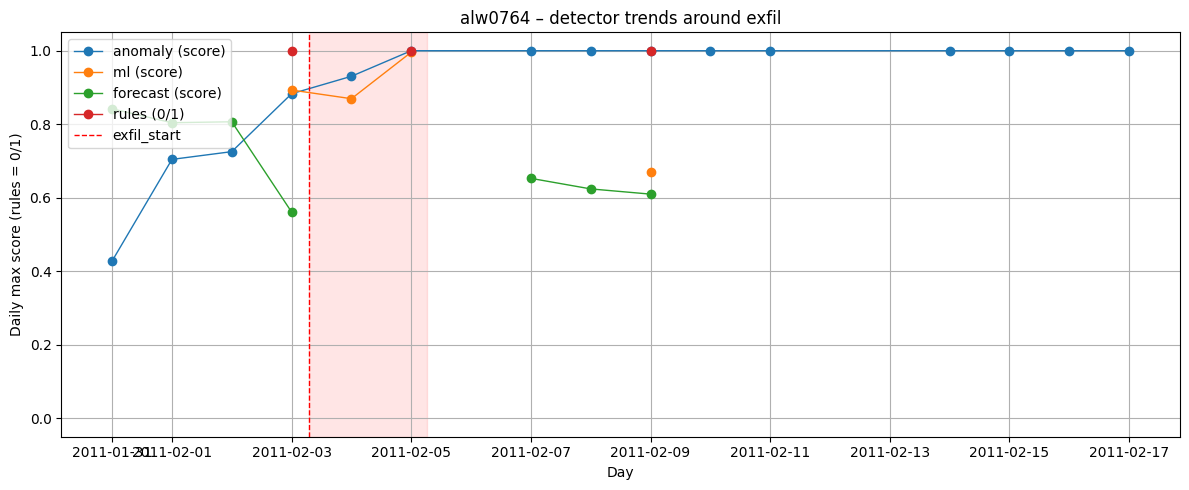

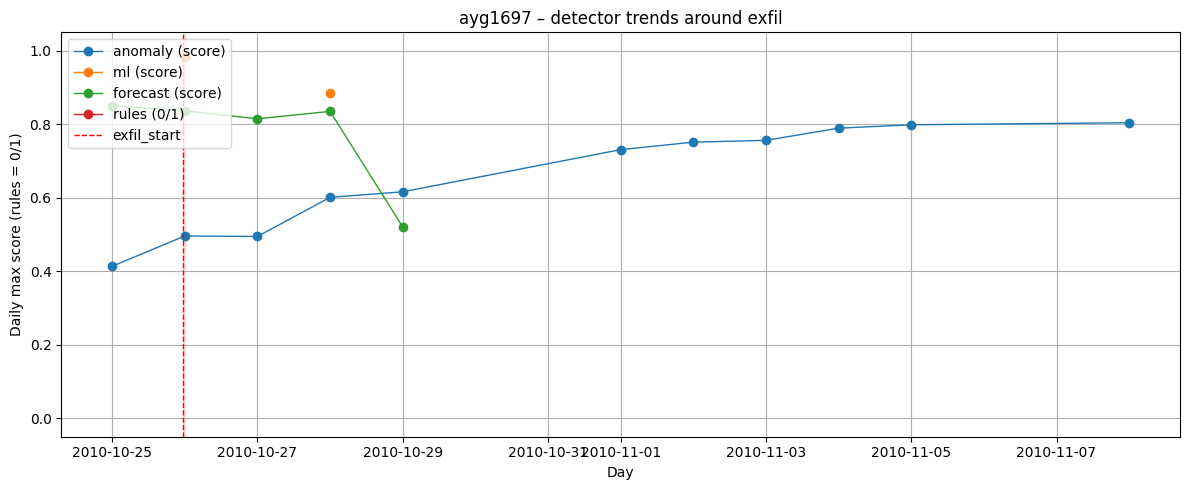

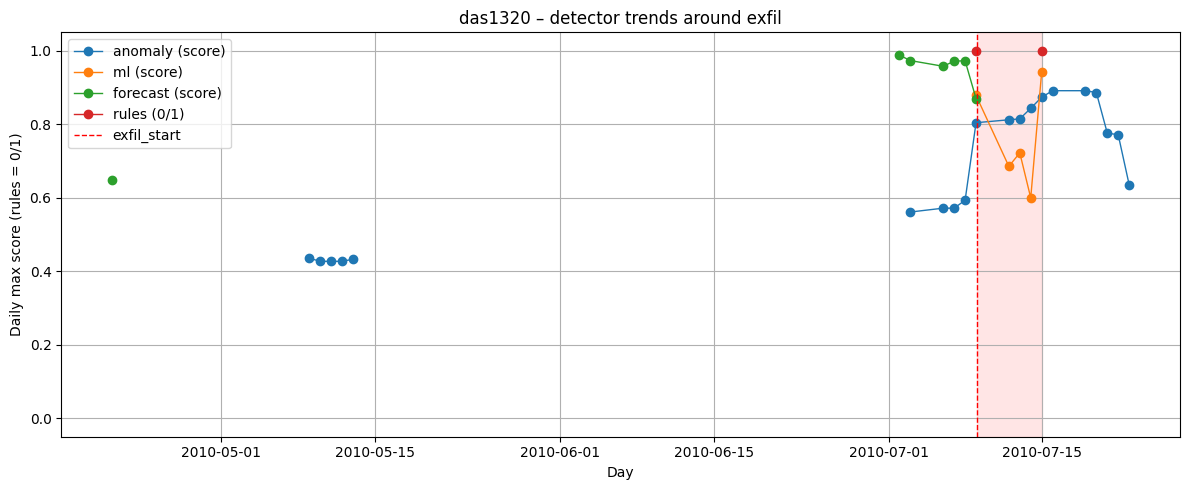

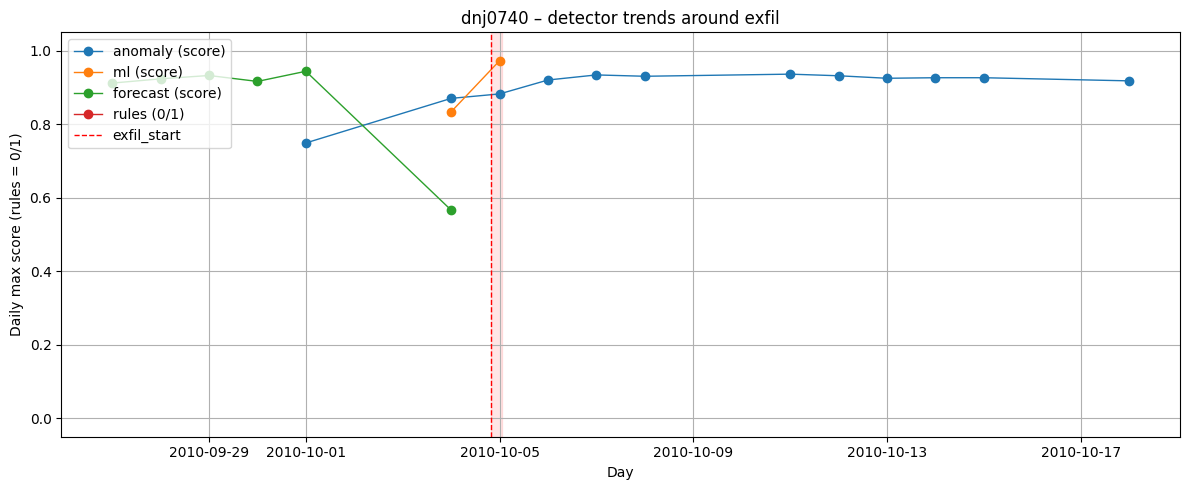

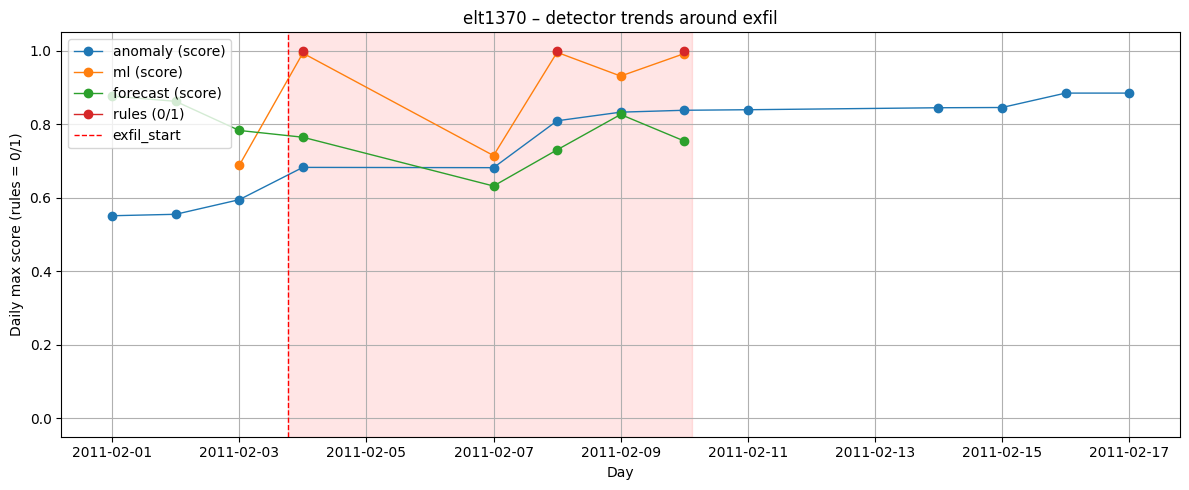

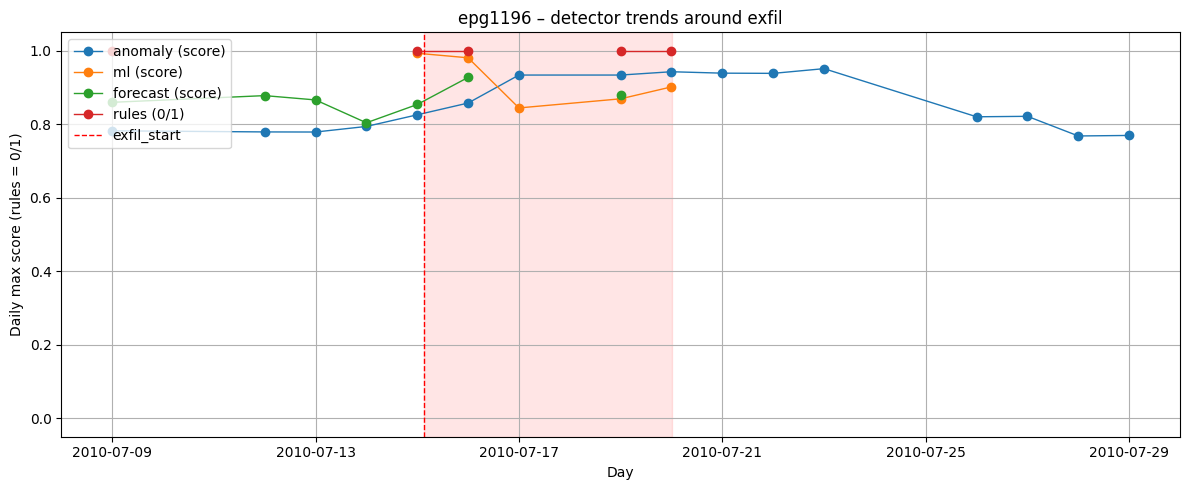

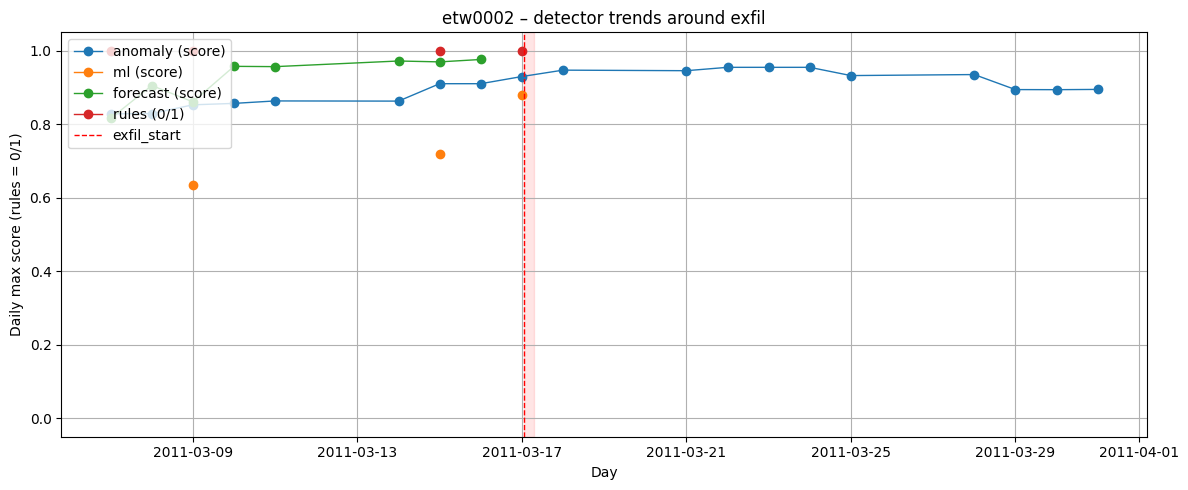

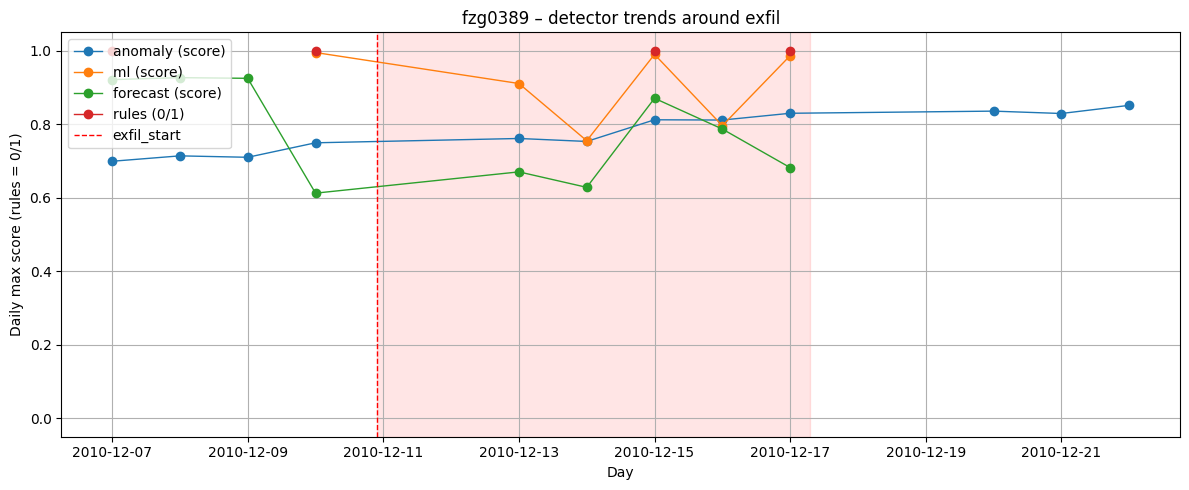

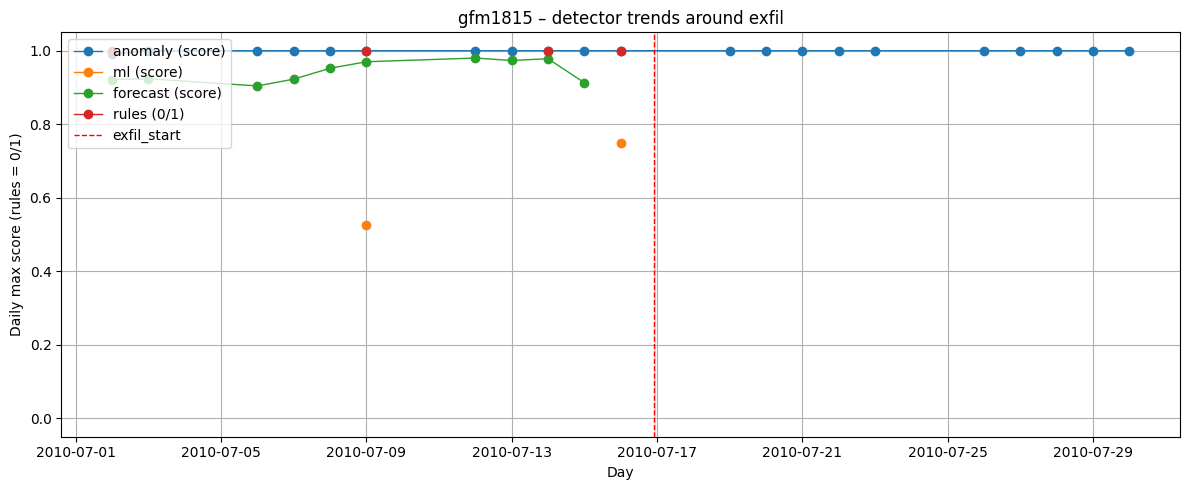

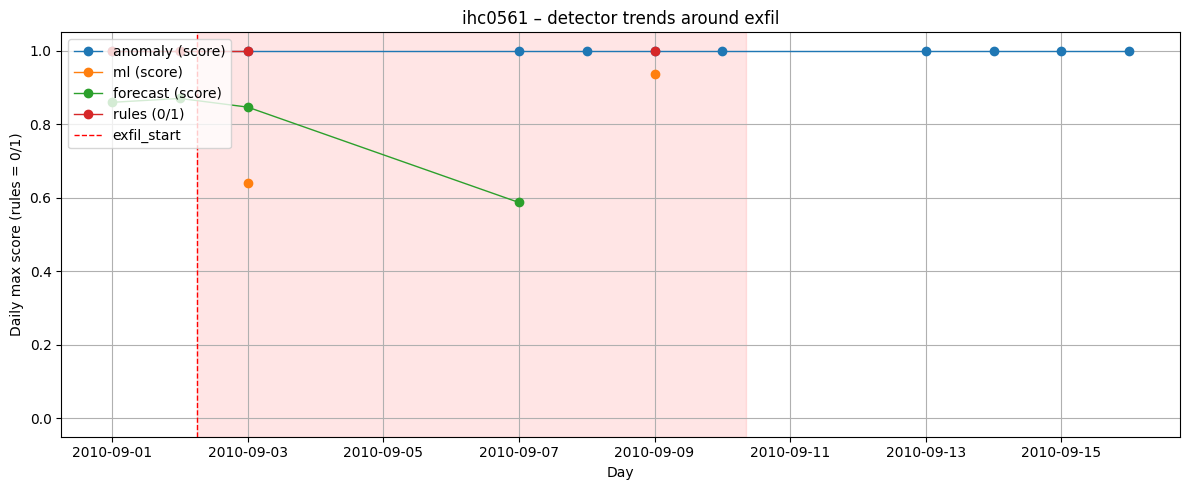

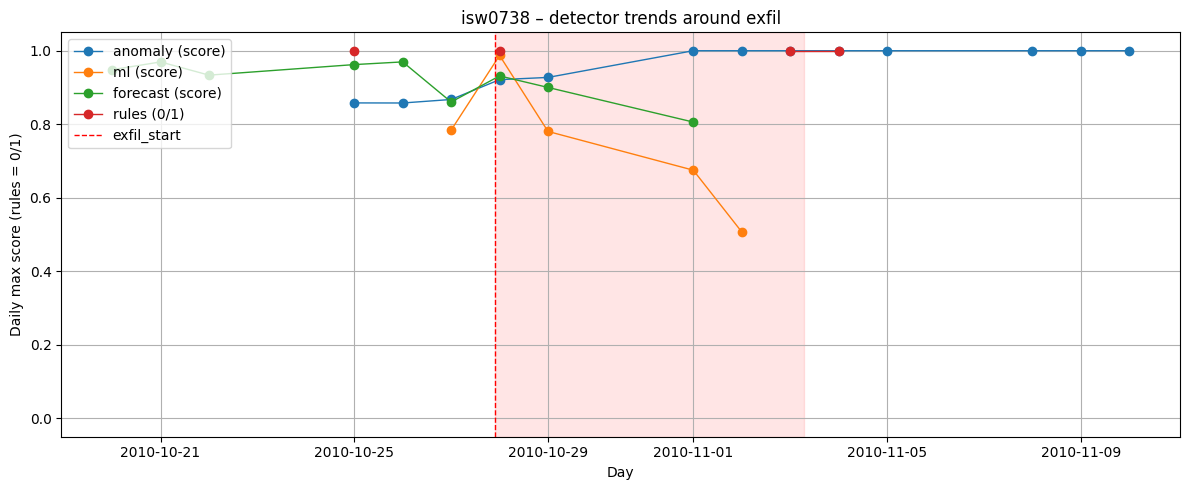

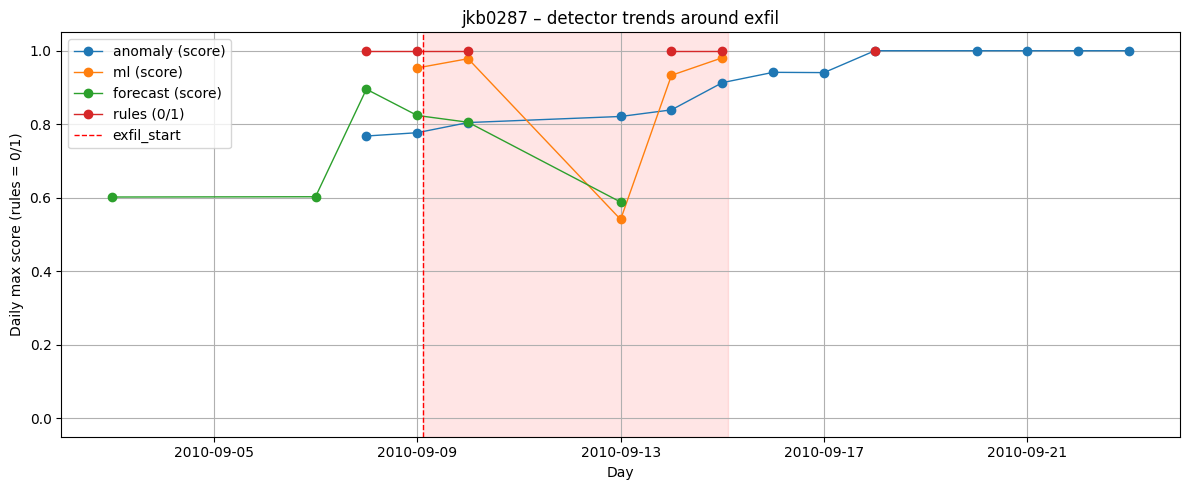

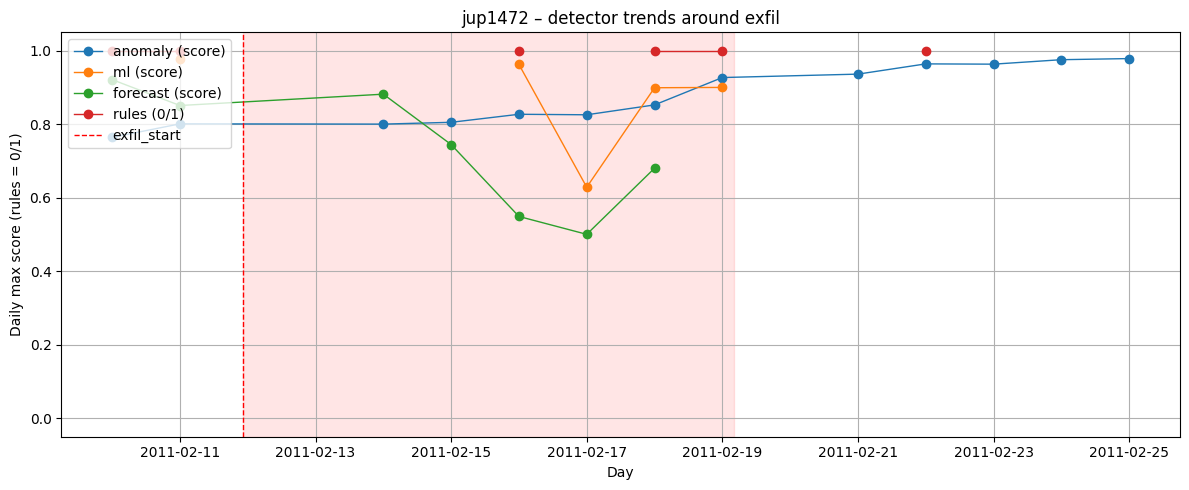

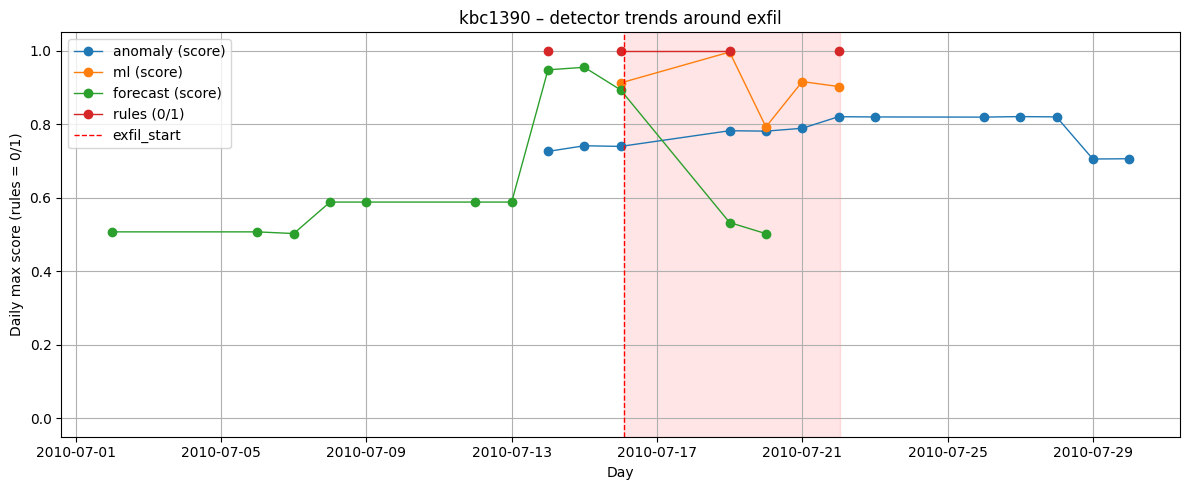

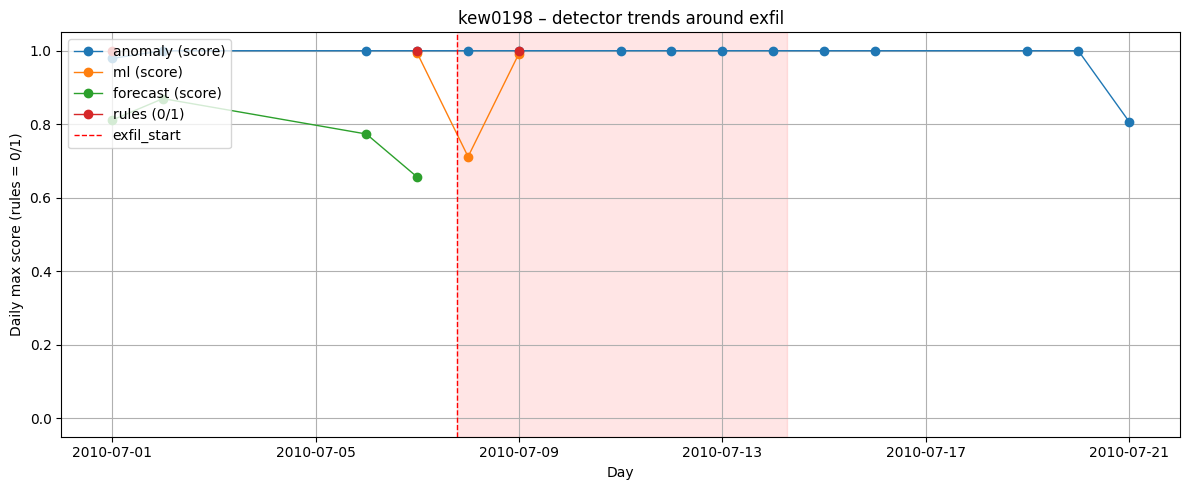

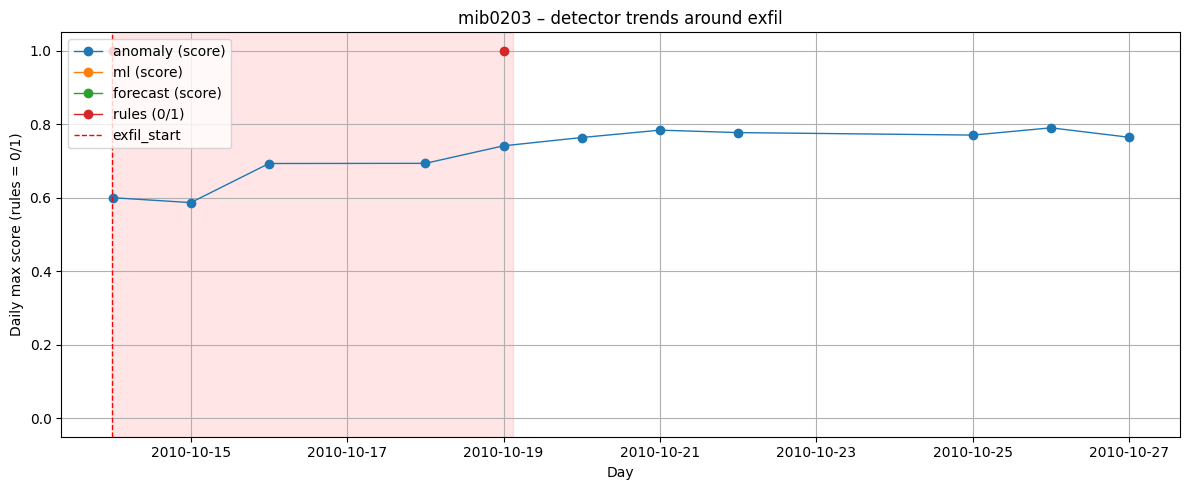

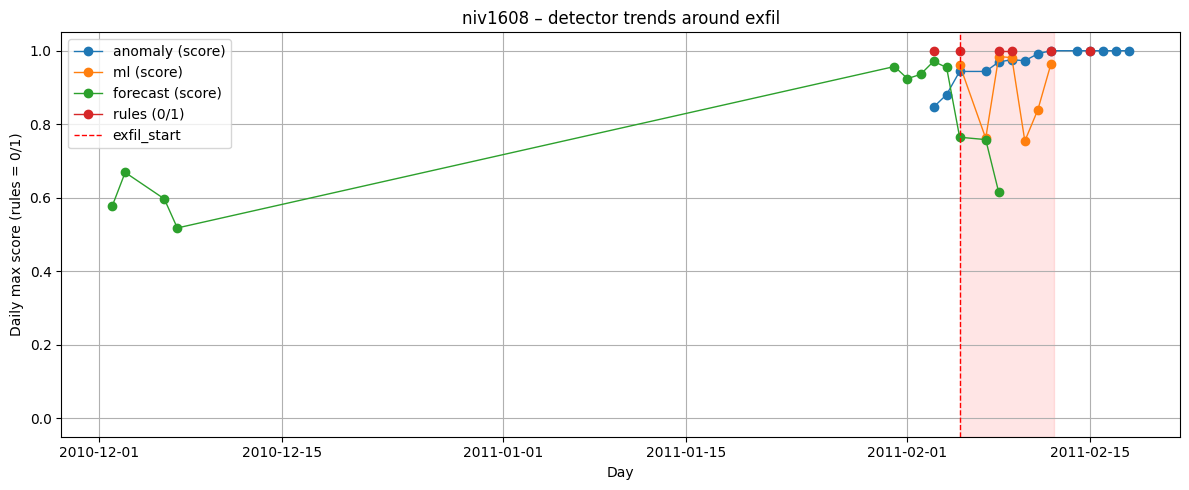

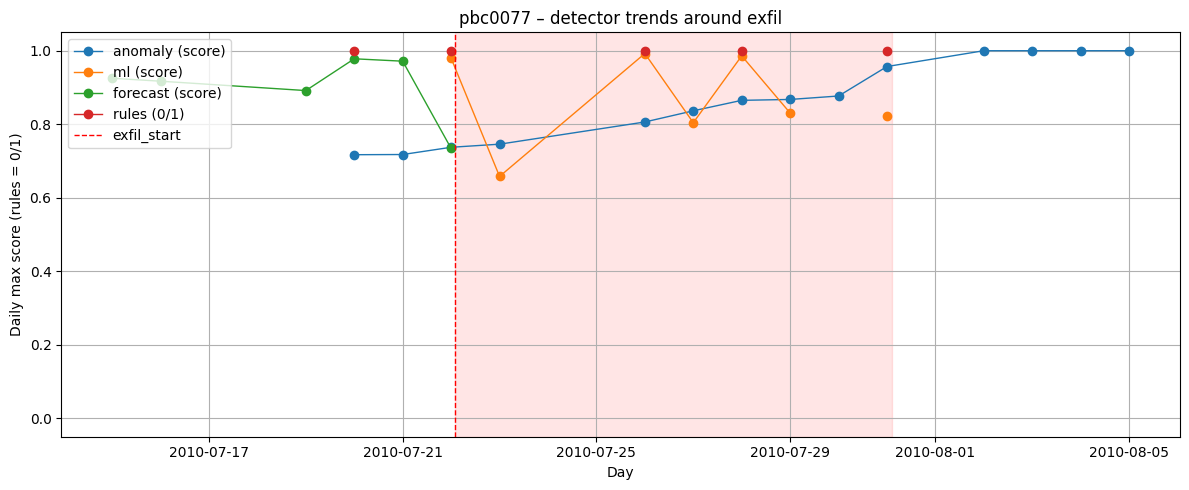

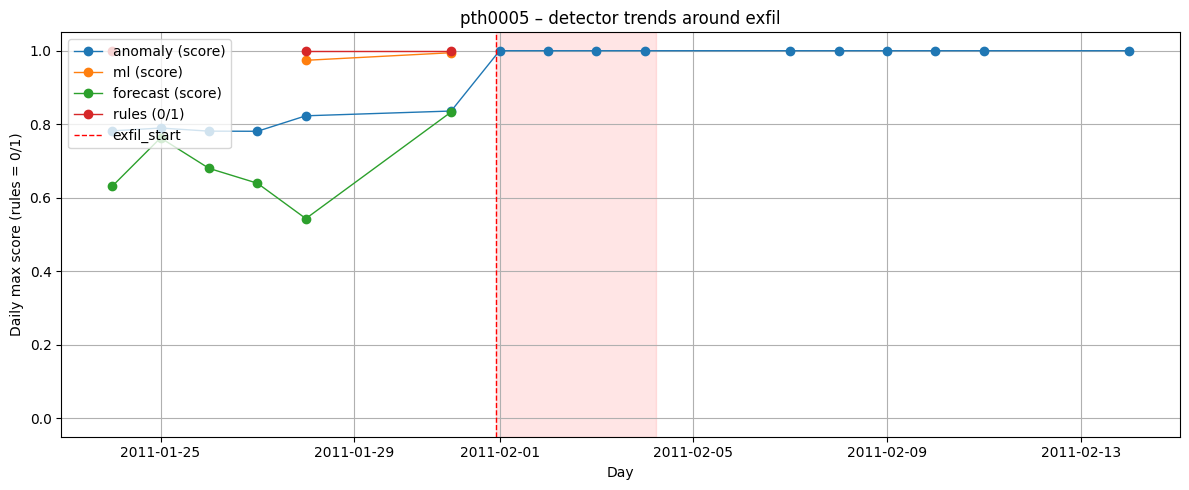

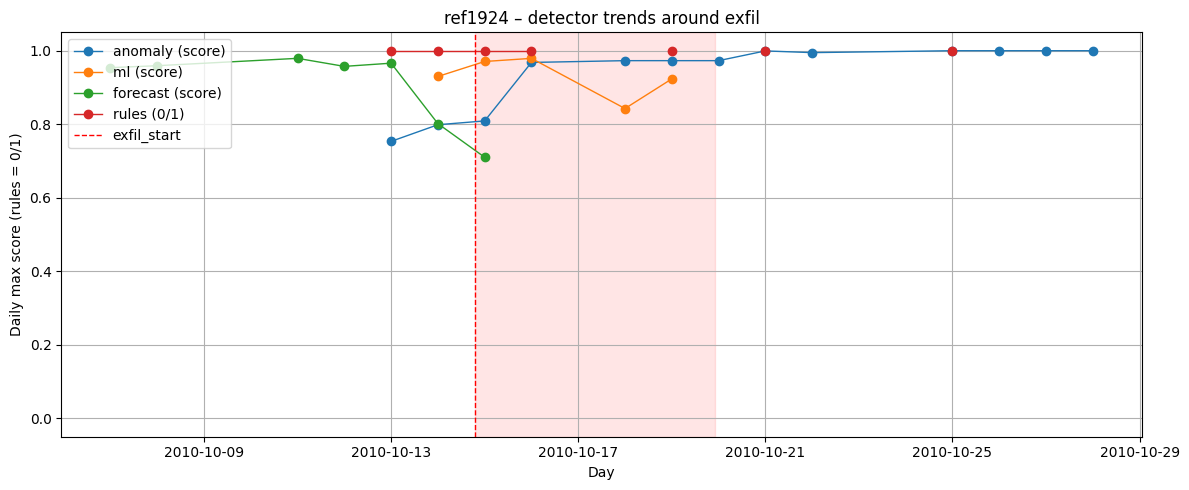

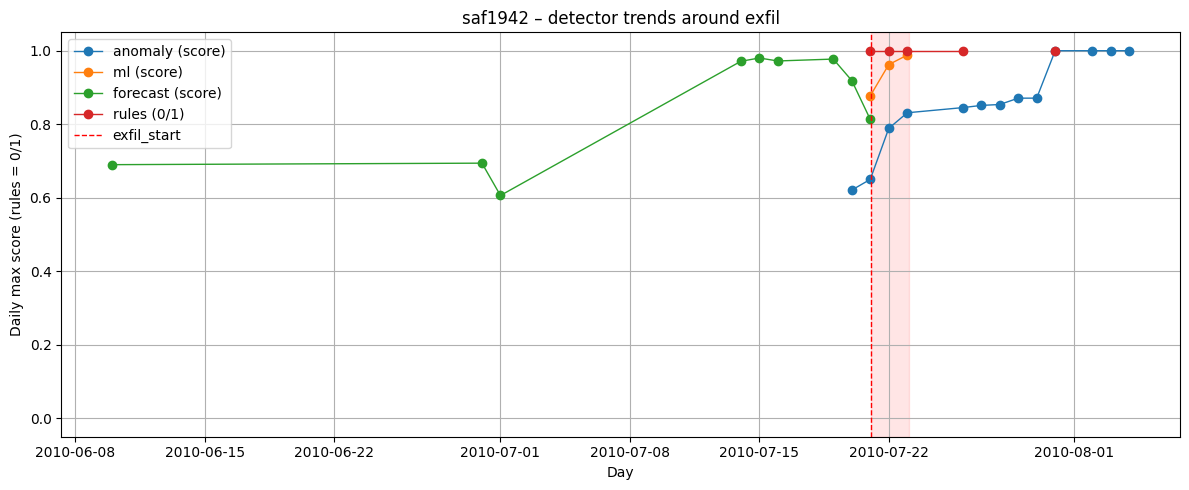

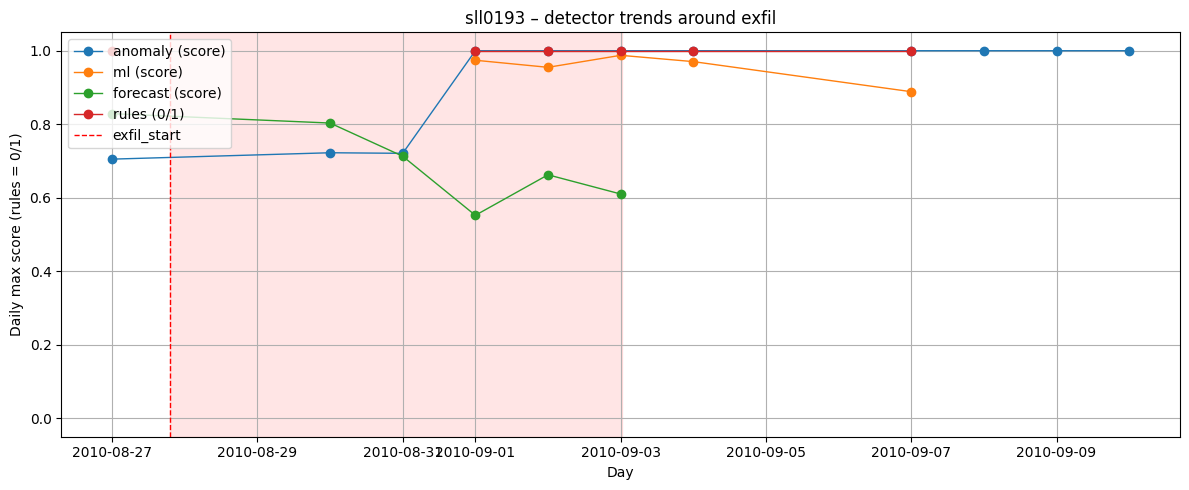

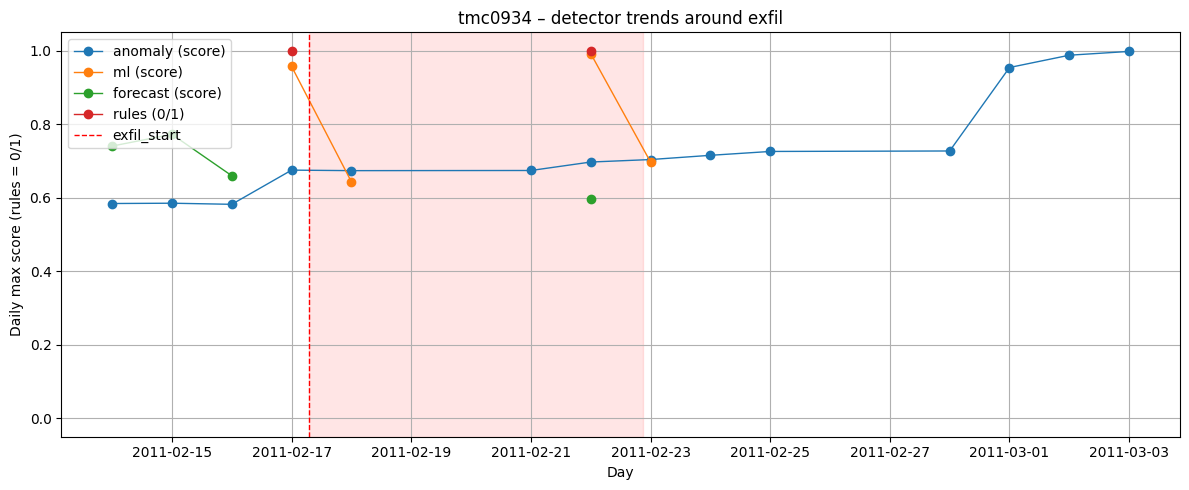

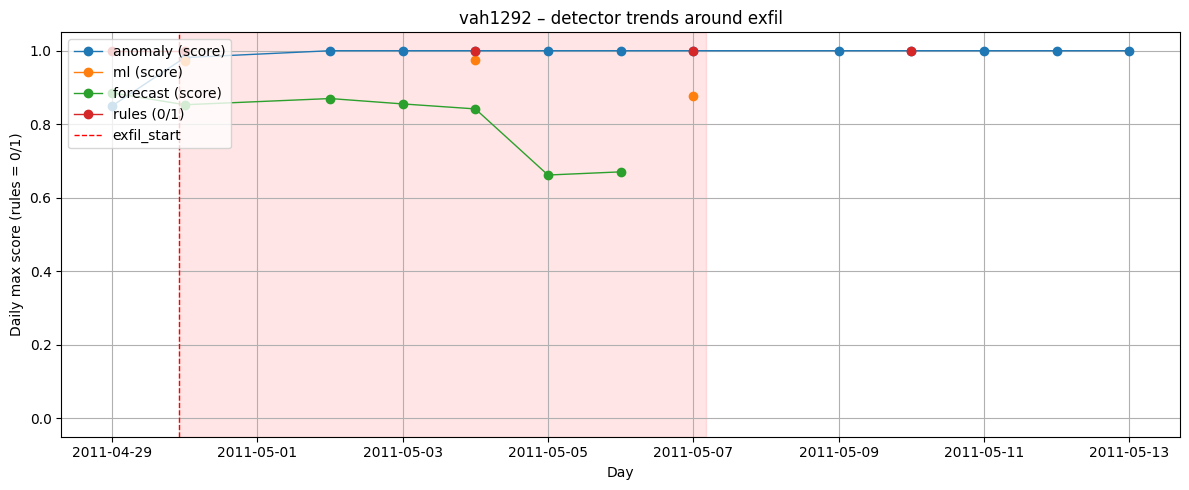

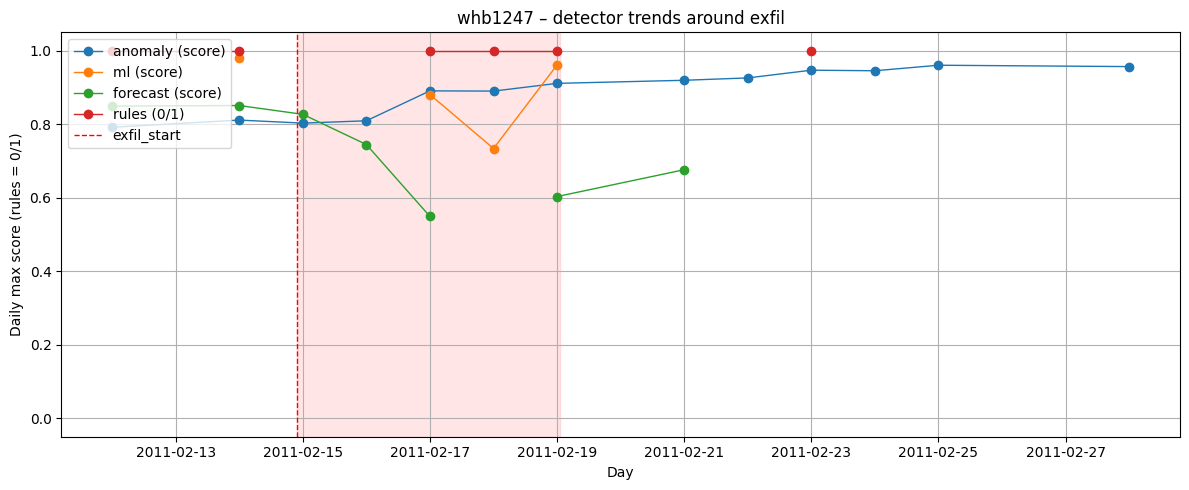

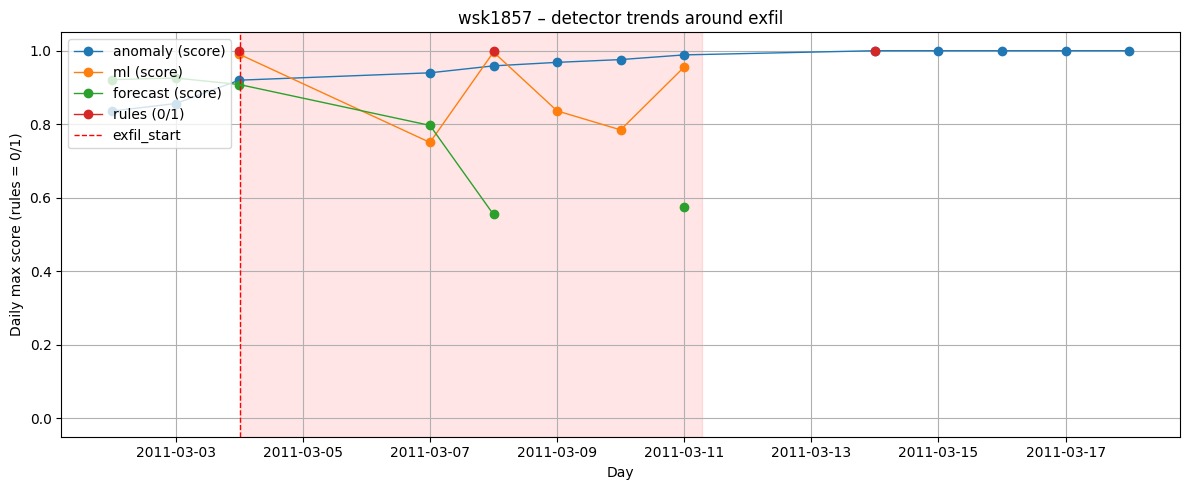

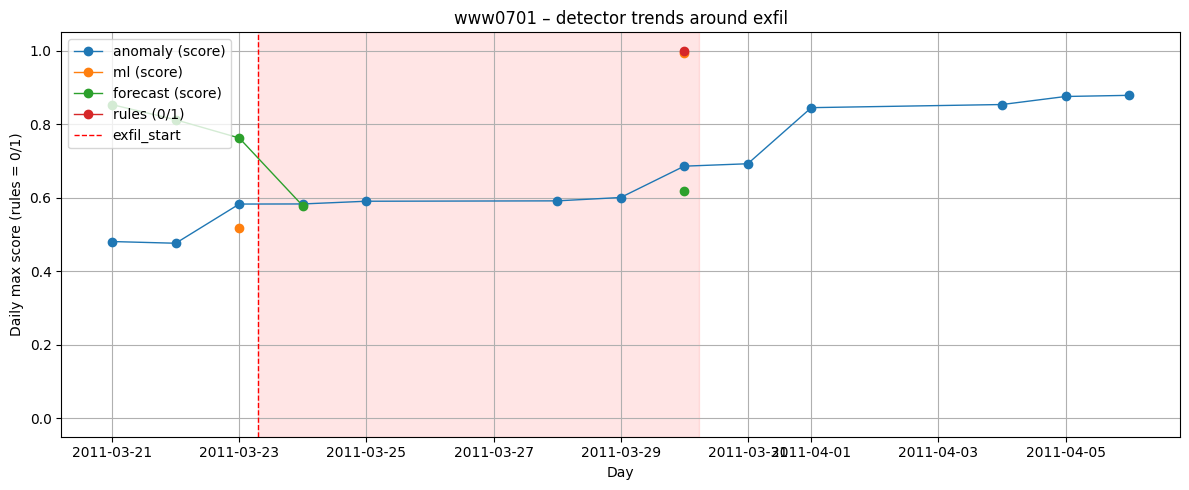

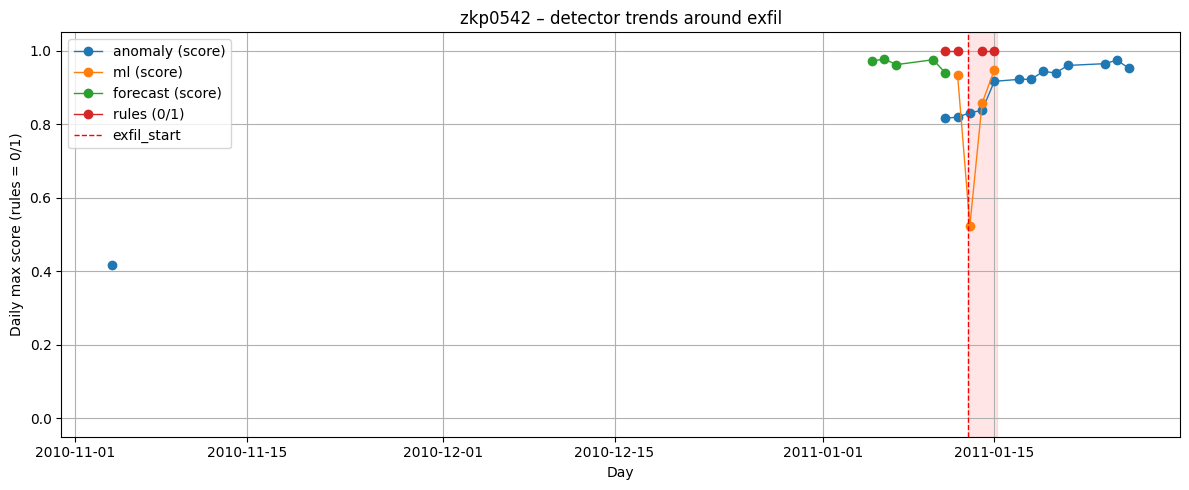

In [15]:
# One plot per Scenario-1 insider
for u in sorted(S1_USERS):
    plot_user_detector_trends(u, days_before=90, days_after=14)